# Road Following — Image Labeling (PC Version)

This notebook loads images from `data/dataset_images`, lets you **click** on the target point, draws the annotation, and saves the labelled image to `data/labelled`.

### File naming convention
Saved files follow the same format as the JetBot collector:  
`xy_<x_enc>_<y_enc>_<uuid>.jpg`  
where `x_enc = int(x_norm * 50 + 50)` and `y_norm` is the click position normalised to **[-1, 1]** relative to the image centre.

---
### Instructions
1. Run **all cells** from top to bottom.
2. An image will appear in the labeling widget below.
3. **Click** on the point where the robot should drive towards.
4. The annotation (green dot → blue dot, red line) will appear — **click again to confirm & save**, or click **Skip** to skip without saving.
5. The next image loads automatically.


## 1. Install / import dependencies

In [1]:
# Install ipympl if not already present (provides interactive matplotlib backend)
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'ipympl', '--quiet'], check=True)
print('Dependencies ready.')

Dependencies ready.


In [1]:
%matplotlib widget

import os
import glob
import shutil
from uuid import uuid1

import numpy as np
import cv2
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display, clear_output

print('All imports OK.')

All imports OK.


## 2. Configure paths

In [3]:
# ── CONFIGURE THESE PATHS ──────────────────────────────────────────────────────
SOURCE_DIR  = '../../data/dataset_images'   # folder containing images to label
OUTPUT_DIR  = '../../data/labelled'         # folder where labelled images are saved
IMG_SIZE    = 224                     # expected image size (must match training)
# ──────────────────────────────────────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Collect all images from source directory (sorted for reproducibility)
EXTENSIONS = ('*.jpg', '*.jpeg', '*.png', '*.bmp')
all_images = []
for ext in EXTENSIONS:
    all_images += glob.glob(os.path.join(SOURCE_DIR, '**', ext), recursive=True)
    all_images += glob.glob(os.path.join(SOURCE_DIR, ext))
all_images = sorted(set(all_images))

# Skip images that were already labelled (same stem present in output dir)
already_labelled_stems = set(
    '_'.join(os.path.basename(p).split('_')[3:]).split('.')[0]   # uuid part
    for p in glob.glob(os.path.join(OUTPUT_DIR, 'xy_*.jpg'))
)
queue = [p for p in all_images]

print(f'Source dir : {SOURCE_DIR}')
print(f'Output dir : {OUTPUT_DIR}')
print(f'Images found : {len(all_images)}')
print(f'In queue     : {len(queue)}')

Source dir : ../../data/dataset_images
Output dir : ../../data/labelled
Images found : 1950
In queue     : 1950


## 3. Labeling widget

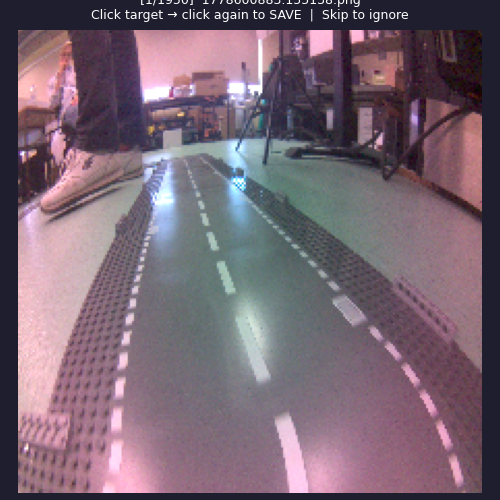

In [5]:
# ── State ─────────────────────────────────────────────────────────────────────
state = {
    'index'        : 0,
    'img_orig'     : None,   # raw numpy image (BGR, 224×224)
    'pending_click': None,   # (x_norm, y_norm) after first click
    'saved'        : 0,
    'skipped'      : 0,
}

# ── Helpers ───────────────────────────────────────────────────────────────────
CENTER_X, CENTER_Y = IMG_SIZE // 2, IMG_SIZE - 1   # bottom-center reference dot

def load_image(path):
    """Load image from disk, resize to IMG_SIZE × IMG_SIZE, return RGB numpy."""
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        raise FileNotFoundError(f'Cannot read image: {path}')
    img_bgr = cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE))
    return img_bgr

def annotate(img_bgr, px, py):
    """Draw green target dot, blue bottom-center dot, red line — return RGB."""
    img = img_bgr.copy()
    cv2.circle(img, (px, py),    8, (0, 255,   0), 3)   # green: target
    cv2.circle(img, (CENTER_X, CENTER_Y), 8, (0,   0, 255), 3)   # blue: robot
    cv2.line(  img, (px, py), (CENTER_X, CENTER_Y), (255, 0, 0), 3)  # red line
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def pixel_to_norm(px, py):
    """Convert pixel coords (0..IMG_SIZE) → normalised (-1..1)."""
    x_norm = (px - IMG_SIZE / 2) / (IMG_SIZE / 2)
    y_norm = (py - IMG_SIZE / 2) / (IMG_SIZE / 2)
    return float(np.clip(x_norm, -1, 1)), float(np.clip(y_norm, -1, 1))

def xy_filename(x_norm, y_norm):
    x_enc = int(x_norm * 50 + 50)
    y_enc = int(y_norm * 50 + 50)
    return f'xy_{x_enc:03d}_{y_enc:03d}_{uuid1()}.jpg'

def save_image(src_path, x_norm, y_norm):
    """Save original (un-annotated) image with encoded filename."""
    fname  = xy_filename(x_norm, y_norm)
    dst    = os.path.join(OUTPUT_DIR, fname)
    # Save the resized original (NOT the annotated version — training needs clean images)
    img_bgr = cv2.imread(src_path)
    img_bgr = cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE))
    cv2.imwrite(dst, img_bgr)
    return dst

# ── Widgets ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')
ax.axis('off')
ax.set_title('Loading…', color='white', fontsize=11, pad=8)
plt.tight_layout(pad=0.5)

status_out = widgets.Output()

btn_skip = widgets.Button(
    description='⏭  Skip',
    button_style='warning',
    layout=widgets.Layout(width='130px', height='36px')
)
btn_undo = widgets.Button(
    description='↩  Undo click',
    button_style='info',
    layout=widgets.Layout(width='140px', height='36px')
)
progress = widgets.IntProgress(
    value=0, min=0, max=max(len(queue), 1),
    description='Progress:',
    bar_style='success',
    layout=widgets.Layout(width='360px')
)
label_info = widgets.Label(value='')

controls = widgets.HBox([btn_skip, btn_undo, progress])
ui = widgets.VBox([fig.canvas, controls, label_info, status_out])

# ── Core logic ────────────────────────────────────────────────────────────────
def refresh_title():
    i, total = state['index'], len(queue)
    if i >= total:
        ax.set_title('✅  All images labelled!', color='#a6e3a1', fontsize=12, pad=8)
        return
    path = queue[i]
    fname = os.path.basename(path)
    ax.set_title(
        f'[{i+1}/{total}]  {fname}\n'
        f'Click target → click again to SAVE  |  Skip to ignore',
        color='white', fontsize=9, pad=8
    )

def show_current():
    i = state['index']
    if i >= len(queue):
        ax.cla()
        ax.axis('off')
        ax.set_title('✅  All images labelled!', color='#a6e3a1', fontsize=13, pad=8)
        fig.canvas.draw_idle()
        return
    img_bgr = load_image(queue[i])
    state['img_orig'] = img_bgr
    state['pending_click'] = None
    ax.cla()
    ax.axis('off')
    ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    refresh_title()
    progress.value = i
    label_info.value = (
        f'Saved: {state["saved"]}   Skipped: {state["skipped"]}   '
        f'Remaining: {len(queue) - i}'
    )
    fig.canvas.draw_idle()

def advance(skip=False):
    if skip:
        state['skipped'] += 1
    state['index'] += 1
    state['pending_click'] = None
    show_current()

def on_click(event):
    if event.inaxes is not ax:
        return
    if state['index'] >= len(queue):
        return

    px = int(round(event.xdata))
    py = int(round(event.ydata))
    px = max(0, min(px, IMG_SIZE - 1))
    py = max(0, min(py, IMG_SIZE - 1))

    if state['pending_click'] is None:
        # First click: show annotation, wait for confirmation
        x_norm, y_norm = pixel_to_norm(px, py)
        state['pending_click'] = (px, py, x_norm, y_norm)
        annotated = annotate(state['img_orig'], px, py)
        ax.cla()
        ax.axis('off')
        ax.imshow(annotated)
        ax.set_title(
            f'x={x_norm:.3f}  y={y_norm:.3f}\n'
            'Click again to SAVE  |  Undo to re-place  |  Skip to ignore',
            color='#f5c2e7', fontsize=9, pad=8
        )
        fig.canvas.draw_idle()
    else:
        # Second click: save and advance
        _, _, x_norm, y_norm = state['pending_click']
        dst = save_image(queue[state['index']], x_norm, y_norm)
        state['saved'] += 1
        with status_out:
            clear_output(wait=True)
            print(f'✅ Saved → {os.path.basename(dst)}')
        advance(skip=False)

def on_skip(_):
    with status_out:
        clear_output(wait=True)
        if state['index'] < len(queue):
            print(f'⏭  Skipped: {os.path.basename(queue[state["index"]])}')
    advance(skip=True)

def on_undo(_):
    if state['index'] >= len(queue):
        return
    state['pending_click'] = None
    ax.cla()
    ax.axis('off')
    ax.imshow(cv2.cvtColor(state['img_orig'], cv2.COLOR_BGR2RGB))
    refresh_title()
    fig.canvas.draw_idle()
    with status_out:
        clear_output(wait=True)
        print('↩  Click undone — place again.')

# ── Wire up events ────────────────────────────────────────────────────────────
fig.canvas.mpl_connect('button_press_event', on_click)
btn_skip.on_click(on_skip)
btn_undo.on_click(on_undo)

# ── Launch ────────────────────────────────────────────────────────────────────
if len(queue) == 0:
    print('⚠️  No images found in', SOURCE_DIR)
    print('   Check that SOURCE_DIR is correct and images are present.')
else:
    show_current()
    display(ui)

## 4. Summary

In [5]:
# Run this cell at any time to see a summary of labelled images
labelled = glob.glob(os.path.join(OUTPUT_DIR, 'xy_*.jpg'))
print(f'Labelled images in {OUTPUT_DIR}: {len(labelled)}')
if labelled:
    print('\nFirst 5 filenames:')
    for p in sorted(labelled)[:5]:
        print(' ', os.path.basename(p))

Labelled images in ../../data/labelled: 304

First 5 filenames:
  xy_004_083_fd123579-4fa5-11f1-b2fa-b0dcefa31e34.jpg
  xy_005_076_498983a5-4fa6-11f1-a534-b0dcefa31e34.jpg
  xy_007_085_15287da7-4fa5-11f1-88bd-b0dcefa31e34.jpg
  xy_009_061_2c8abef1-4fa4-11f1-893e-b0dcefa31e34.jpg
  xy_009_070_97936475-4fa5-11f1-8e6a-b0dcefa31e34.jpg


## 5. (Optional) Verify a random labelled image

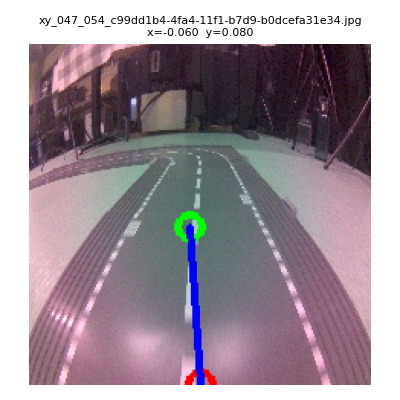

In [33]:
import random

labelled = glob.glob(os.path.join(OUTPUT_DIR, 'xy_*.jpg'))
if not labelled:
    print('No labelled images yet.')
else:
    path = random.choice(labelled)
    fname = os.path.basename(path)
    parts = fname.split('_')
    x_enc, y_enc = int(parts[1]), int(parts[2])
    x_norm = (x_enc - 50) / 50
    y_norm = (y_enc - 50) / 50
    px = int(x_norm * IMG_SIZE / 2 + IMG_SIZE / 2)
    py = int(y_norm * IMG_SIZE / 2 + IMG_SIZE / 2)

    img_bgr = cv2.imread(path)
    annotated = annotate(img_bgr, px, py)

    fig2, ax2 = plt.subplots(figsize=(4, 4))
    ax2.imshow(annotated)
    ax2.axis('off')
    ax2.set_title(f'{fname}\nx={x_norm:.3f}  y={y_norm:.3f}', fontsize=8)
    plt.tight_layout()
    plt.show()